In [11]:
import numpy as np
import matplotlib.pyplot as plt

## Interpolazione di funzioni

Si parla di interpolazione di funzioni quando i punti da interpolare appartengono al grafico di un'altra funzione, la cui espressione analitica può essere nota oppure no.

In altri termini, si assume che le ordinate dei punti $(x_i,y_i)$, siano le immagini dei nodi tramite una funzione $f$, ossia
$$y_i =f(x_i), \ \ i=0,\dots,n $$

In questo caso, se $p(x)$ è una funzione interpolante i dati $(x_i,y_i)$, si dice anche che interpola la funzione $f$.

**Esempio** di interpolazione di una funzione nota,
$$ \frac{\sin(6x)(3x)^2}{3x+4}$$
rispetto ai nodi $[0,1,1.5,2]$

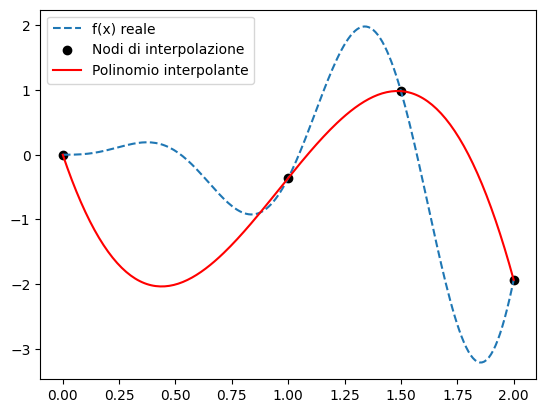

In [12]:
# =======================
# DEFINIZIONE DELLA FUNZIONE
# =======================

# Definiamo una funzione f(x) non banale.
# Verrà usata come "funzione reale" da approssimare/interpolare.
f = lambda x: np.sin(6 * x) * (3 * x) ** 2 / (3 * x + 4)


# =======================
# GRAFICO DELLA FUNZIONE REALE
# =======================

# Creiamo molti punti per disegnare una curva liscia
xx = np.linspace(0, 2, num=200)

# Valutiamo la funzione sui punti
yy = f(xx)

# Disegniamo la funzione reale con linea tratteggiata
plt.plot(xx, yy, '--', label="f(x) reale")


# =======================
# SCELTA DEI PUNTI DI INTERPOLAZIONE
# =======================

# Selezioniamo pochi punti (nodi) su cui costruire il polinomio
x = np.array([0, 1, 1.5, 2])

# Calcoliamo i valori della funzione in questi punti
y = f(x)

# Disegniamo i punti usati per interpolare
plt.scatter(x, y, color='black', label="Nodi di interpolazione")


# =======================
# COSTRUZIONE DEL POLINOMIO INTERPOLANTE
# =======================

# Costruiamo il polinomio di grado n-1 che interpola tutti i punti
# polyfit restituisce i coefficienti in ordine decrescente
b = np.polyfit(x, y, x.size - 1)

# Valutiamo il polinomio sugli stessi punti xx (per confronto visivo)
zz = np.polyval(b, xx)


# =======================
# GRAFICO DEL POLINOMIO
# =======================

# Disegniamo il polinomio interpolante (in rosso)
plt.plot(xx, zz, '-r', label="Polinomio interpolante")


# =======================
# RISULTATO FINALE
# =======================

plt.legend()
plt.show()

**Significato del risultato**

Nel grafico possiamo interpretare la funzione tratteggiata come il comportamento reale di un fenomeno fisico nel tempo. Questa funzione è continua, ma nella pratica non è possibile osservarla in tutti i punti: possiamo solo effettuare un numero finito di misurazioni.

I punti neri rappresentano proprio queste osservazioni discrete $(x_i, y_i)$. Sono dati sperimentali, spesso pochi e separati tra loro.

Il polinomio interpolante (linea rossa) è una funzione costruita a partire da questi punti, che li attraversa esattamente. In questo senso, rappresenta una **ricostruzione del fenomeno** basata esclusivamente sui dati disponibili.

Questa funzione non è necessariamente uguale alla funzione reale, ma è una sua **approssimazione**. Tra i punti noti, il polinomio “riempie i vuoti” fornendo una stima del comportamento del sistema.

È importante capire che:
- nei nodi di interpolazione l’approssimazione è perfetta ($p(x_i) = y_i$),
- tra i nodi, invece, il comportamento dipende dalla qualità del modello e dalla distribuzione dei punti.

In sintesi, l’interpolazione polinomiale permette di passare da dati discreti a una funzione continua, utile per analisi, simulazioni e previsioni.

**Il polinomio di interpolazione di una funzione può essere considerato una approssimazione della funzione stessa?**

* Sebbene si possa formalizzare il concetto di "approssimazione
di una funzione", cerchiamo di rispondere alla domanda ragionando sulla somiglianza tra il grafico di $f$ e quello del suo polinomio di interpolazione.

* Nell'esempio precedente, i due grafici non sono particolarmente simili. Per renderli più vicini, una strategia ragionevole potrebbe essere quella di utilizzare un maggior numero di nodi nell'intervallo.

Sperimentiamo la correttezza di questa supposizione, scegliendo $n$ nodi equispaziati nell'intervallo di riferimento. Proviamo i valori $n=4$ e $n=15$.

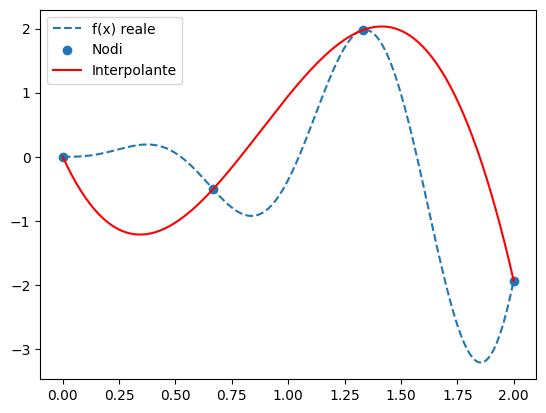

In [13]:
# =======================
# OSSERVAZIONE: Aumentando il numero di punti (nodi), il polinomio interpolante
#               tende ad approssimare meglio la funzione reale.
# =======================

# Numero di punti di interpolazione (prova a variare, es: da 4 a 15)
n = 4

# Generiamo n punti equispaziati nell'intervallo [0, 2]
# Più n aumenta --> punti più ravvicinati --> più informazione sulla funzione
x = np.linspace(0, 2, num=n)

# Valutiamo la funzione nei nodi scelti
y = f(x)

# Costruiamo il polinomio interpolante di grado n-1
# (interpola esattamente tutti i punti)
b = np.polyfit(x, y, x.size - 1)

# Valutiamo il polinomio su una griglia fitta (per disegno fluido)
zz = np.polyval(b, xx)


# =======================
# GRAFICO
# =======================

# Funzione reale (linea tratteggiata)
plt.plot(xx, yy, '--', label="f(x) reale")

# Punti di interpolazione
plt.scatter(x, y, label="Nodi")

# Polinomio interpolante
plt.plot(xx, zz, '-r', label="Interpolante")

plt.legend()
plt.show()


# =======================
# NOTA IMPORTANTE:
# Aumentare n NON garantisce sempre un miglioramento globale.
# Con molti punti equispaziati possono comparire oscillazioni
# (fenomeno di Runge), soprattutto vicino agli estremi.
#
# Quindi:
# - più punti --> più informazione locale
# - ma anche rischio di instabilità numerica
# =======================

Nell'esempio precedente la strategia di scegliere un numero maggiore di nodi sempre più vicini tra loro sembra dare buoni risultati, poiché i grafici del polinomio di interpolazione su 15 nodi e quello della funzione stessa sono sostanzialmente sovrapposti.

**Questa conclusione è vera in generale per qualsiasi funzione?**

Ripetiamo l'esperimento sulla funzione seguente
$$f(x) = \frac{1}{1+25x^2} $$
(detta funzione di Runge), utilizzando **nodi equispaziati** in numero crescente
nell'intervallo $[-1,1]$.

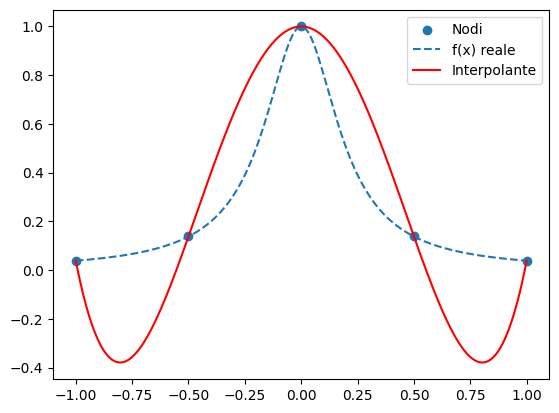

In [14]:
# =======================
# FUNZIONE DI RUNGE
# =======================

# Questa funzione è un classico esempio usato per mostrare
# i problemi dell'interpolazione polinomiale con punti equispaziati
f = lambda x: 1 / (1. + 25 * x**2)


# =======================
# SCELTA DEI NODI
# =======================

# Numero di punti (prova a variare da 5 a 15 o più)
n = 5

# Nodi equispaziati nell'intervallo [-1, 1]
x = np.linspace(-1, 1, num=n)

# Valori della funzione nei nodi
y = f(x)

# Disegniamo i punti di interpolazione
plt.scatter(x, y, label="Nodi")


# =======================
# COSTRUZIONE DEL POLINOMIO
# =======================

# Polinomio interpolante di grado n-1
b = np.polyfit(x, y, x.size - 1)


# =======================
# VALUTAZIONE SU GRIGLIA FINE
# =======================

# Punti fitti per visualizzare bene le curve
xx = np.linspace(-1, 1, num=200)

# Valori della funzione reale
yy = f(xx)

# Valori del polinomio interpolante
zz = np.polyval(b, xx)


# =======================
# GRAFICO
# =======================

# Funzione reale (tratteggiata)
plt.plot(xx, yy, '--', label="f(x) reale")

# Polinomio interpolante (rosso)
plt.plot(xx, zz, '-r', label="Interpolante")

plt.legend()
plt.show()


# =======================
# NOTA IMPORTANTE (EFFETTO RUNGE)
# =======================
# Aumentando il numero di punti equispaziati (n),
# il polinomio NON sempre migliora globalmente.
#
# In particolare:
# - vicino agli estremi dell'intervallo [-1, 1]
#   compaiono forti oscillazioni
# - questo fenomeno è detto "fenomeno di Runge"
#
# Quindi:
# - più punti ≠ sempre migliore approssimazione
# - la scelta dei nodi è fondamentale (es. nodi di Chebyshev)
# =======================

L'effetto che osserviamo viene riferito come **fenomeno di Runge**: scegliendo nodi equispaziati, all'aumentare del loro numero e, di conseguenza del grado del polinomio interpolante, l'approssimazione peggiora in prossimità degli estremi dell'intervallo, mentre si ha una buona sovrapposizione nella parte centrale.

**Come si può evitare questo deterioramento dell'approssimazione ottenuta col polinomio?**

L'intuizione è di scegliere i nodi non in modo uniforme nell'intervallo, ma in modo che siano più fitti in prossimità degli estremi, dove c'è bisogno di maggior controllo.

Questo è il criterio dei **nodi di Chebychev**



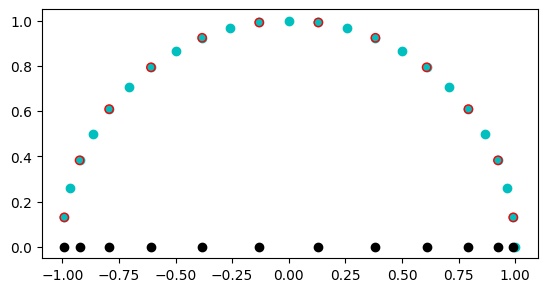

In [ ]:
# Costruzione dei nodi di Chebychev

fig,ax = plt.subplots()
ax.set_aspect("equal")

#1. Definiamo il numero di nodi da creare
n = 11

#3. Partizioniamo gli angoli tra [0,pi] in 2(n+1) parti uguali
theta = np.pi/2/(n+1)*np.arange(2*(n+1))

#4. Plottiamo i punti corrispondenti sulla circonferenza goniometrica
ax.scatter(np.cos(theta),np.sin(theta),c='c')

#5. Selezioniamo solo i punti con indice dispari
beta = theta[1::2]
ax.scatter(np.cos(beta),np.sin(beta),edgecolor='r',facecolor='None')

#6. Otteniamo finalmente i nodi di Chebychev come le ascisse dei punti selezionati
ax.scatter(np.cos(beta),np.zeros(beta.size),c='k')


plt.show()



In sintesi, la formula dei nodi di Chebychev nell'intervallo $[-1,1]$ è la seguente
$$x_i = \cos\left(\frac{(2i+1)\pi}{2(n+1)} \right),\ \ i=0,\dots,n $$

Ripetiamo l'esperimento con la funzione di Runge e nodi di Chebychev.

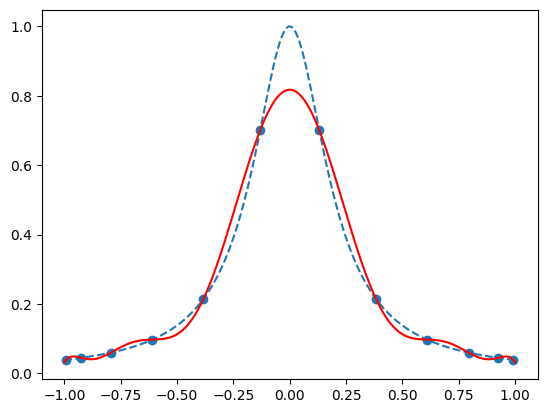

In [20]:
f = lambda x: 1/(1.+25*x**2)
n = 11
x = np.cos((2*np.arange(n+1)+1)*np.pi/2/(n+1)) #nodi di Chebychev
y = f(x)
plt.scatter(x,y)
b = np.polyfit(x,y,x.size-1) #coefficienti del polinomio

#Creazione dei grafici
xx = np.linspace(-1,1,num=200)
yy = f(xx)
zz = np.polyval(b,xx)
plt.plot(xx,yy,'--')
plt.plot(xx,zz,'-r')
plt.show()

In questo caso, aumentando il numero dei nodi, l'accuratezza dell'approssimazione migliora.

Si può dimostrare che la scelta dei nodi di Chebychev è **ottimale** nel senso che, tra tutte le infinite scelte possibili per i nodi di interpolazione, è quella che rende migliore l'approssimazione del polinomio rispetto alla funzione interpolata.